# Structured MVN sampling dispatch — keeping the root cheap

Sampling from $\mathcal{N}(\mu, \Sigma)$ via the reparameterisation trick (already met as [](multivariate_gaussian.ipynb#eq:mvn-sample)) is

```{math}
:label: eq:reparam
x \;=\; \mu \;+\; R\,\varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, I),
\qquad R\,R^\top = \Sigma.
```

The matrix $R$ is *any* root of $\Sigma$. The cheapest choice depends on what $\Sigma$ looks like:

| $\Sigma$ structure | Best root | Cost (square $n \times n$) |
|--------------------|-----------|----------------------------|
| Dense | Cholesky $L$ | $O(n^3)$ |
| **Diagonal** | $\sqrt{\mathrm{diag}}$ — element-wise | $O(n)$ |
| **Kronecker** $A \otimes B$ | $\mathrm{chol}(A) \otimes \mathrm{chol}(B)$ | $O(n_A^3 + n_B^3)$ instead of $(n_A n_B)^3$ |
| **Block-diagonal** $\mathrm{diag}(A_1, \ldots, A_K)$ | $\mathrm{diag}(\mathrm{chol}(A_1), \ldots, \mathrm{chol}(A_K))$ | $\sum_k O(n_k^3)$ |
| **Block-tridiagonal** (Markov chain) | Banded Cholesky → `LowerBlockTriDiag` | $O(N d^3)$ instead of $(Nd)^3$ |
| Low-rank update $\Sigma_0 + UDU^\top$ | No closed-form root; sample $L_0\varepsilon_0 + U\sqrt{D}\,\varepsilon_1$ as two independent draws | varies |
| Toeplitz / KroneckerSum / SumKronecker | Falls back to dense in gaussx today; smart routes (FFT / eigen / Lanczos) are listed in §9 below | $O(n^3)$ until wired |

This is exactly what `gaussx.cholesky` and `gaussx.sqrt` do — **dispatch on operator type** and return a *structured* root operator of the same family. Sampling stays cheap automatically.

This notebook walks the dispatch table:

1. dense baseline ([](multivariate_gaussian.ipynb#eq:mvn-sample) recap with `gaussx.cholesky`),
2. **diagonal** — element-wise sqrt, the simplest dispatch,
3. **Kronecker root identity** + Monte-Carlo cross-check,
4. **BlockDiag root identity** + per-block parallelism,
5. **BlockTriDiag → LowerBlockTriDiag** — banded Cholesky for Markov-chain precisions,
6. low-rank update — what gaussx does when there's no closed-form root,
7. Cholesky vs symmetric square root (when each one is the right answer),
8. timing: structured roots scale with the *factor* size, not the product,
9. operators that currently fall back to dense (Toeplitz / KroneckerSum / SumKronecker) and what their *smart* roots would be.

Prerequisites: [0.1 — Multivariate Gaussian](multivariate_gaussian.ipynb) (especially [](multivariate_gaussian.ipynb#eq:mvn-sample) and [](multivariate_gaussian.ipynb#eq:cov-eig)), [0.2 — `MultivariateNormal` API](mvn_distribution_api.ipynb).

In [1]:
from __future__ import annotations

import time
import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
import gaussx
from gaussx import (
    BlockDiag,
    Kronecker,
    LowRankUpdate,
    MultivariateNormal,
    cholesky,
    sqrt as op_sqrt,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})


def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

## Sampling = a single matvec against any root

Once you have a root $R$ with $R R^\top = \Sigma$, drawing samples is a `matmul`:

```{math}
:label: eq:reparam-batch
X \;=\; \mu \;+\; \varepsilon\,R^\top, \qquad \varepsilon \in \mathbb{R}^{S \times n} \;\sim\; \mathcal{N}(0, I).
```

`gaussx.cholesky(Sigma_op)` returns a *structured* operator $L$ of the same family as $\Sigma$. Multiplying noise through $L$ via `mv` (or composed `Kronecker`/`BlockDiag` ops) keeps the structure all the way down — you never materialise the dense $L$.

:::{tip} ELI5
Sampling a Gaussian = "shoot Gaussian noise through a square-root of $\Sigma$." The square-root has many faces (Cholesky, eigen, symmetric sqrt) — pick the one your $\Sigma$ wears for free.
:::

## 1. Dense baseline

For an arbitrary SPD $\Sigma$ the standard recipe is the Cholesky factor:

```{math}
:label: eq:cholesky-root
\Sigma \;=\; L\,L^\top, \quad L \text{ lower triangular},
\qquad x \;=\; \mu + L\,\varepsilon.
```

`gaussx.cholesky` on a `MatrixLinearOperator` returns the dense Cholesky as a new `MatrixLinearOperator`.

In [2]:
n = 6
key, k_M, k_eps = jax.random.split(KEY, 3)
M = jax.random.normal(k_M, (n, n))
Sigma_dense = M @ M.T + 0.5 * jnp.eye(n)
Sigma_op    = psd_op(Sigma_dense)

L_op = cholesky(Sigma_op)
L    = L_op.as_matrix()
print("L type :", type(L_op).__name__)
print("L L^T - Sigma  ||F  =",
      f"{float(jnp.linalg.norm(L @ L.T - Sigma_dense)):.2e}")

# Sample 50000 draws and compare empirical covariance.
S = 50_000
mu = jnp.zeros(n)
eps = jax.random.normal(k_eps, (S, n))
X = mu + einx.dot("s a, b a -> s b", eps, L)
Sigma_emp = einx.dot("s i, s j -> i j", X, X) / S

print("dense  ||Sigma_emp - Sigma||_F  =",
      f"{float(jnp.linalg.norm(Sigma_emp - Sigma_dense)):.2e}    "
      f"(MC noise ~ ||Sigma||_F * n / sqrt(S))")

L type : MatrixLinearOperator
L L^T - Sigma  ||F  = 2.53e-15


dense  ||Sigma_emp - Sigma||_F  = 1.39e-01    (MC noise ~ ||Sigma||_F * n / sqrt(S))


## 2. Diagonal — the simplest dispatch

When $\Sigma = \mathrm{diag}(\sigma_1^2, \ldots, \sigma_n^2)$, the Cholesky is element-wise:

```{math}
:label: eq:diag-root
\mathrm{chol}\bigl(\mathrm{diag}(\sigma_1^2, \ldots, \sigma_n^2)\bigr) \;=\; \mathrm{diag}(\sigma_1, \ldots, \sigma_n).
```

`gaussx.cholesky(DiagonalLinearOperator(d))` returns another `DiagonalLinearOperator` — no $n \times n$ matrix is ever materialised. Sampling is one element-wise multiply.

This is the structural foundation of *mean-field* variational inference (where $\Sigma$ is constrained diagonal by design) and of factorised Gaussian priors.

In [3]:
key, k_eps = jax.random.split(KEY)
n_diag = 8
diag_var = jnp.array([4.0, 1.0, 9.0, 0.25, 2.5, 0.5, 16.0, 1.5])
D_op = lx.DiagonalLinearOperator(diag_var)

L_D = cholesky(D_op)
print("L type :", type(L_D).__name__)
print("L diag :", np.asarray(L_D.diagonal))
print("L diag = sqrt(var)?", bool(jnp.allclose(L_D.diagonal, jnp.sqrt(diag_var))))

# Sample 50000 draws -- one element-wise multiply per draw.
S = 50_000
eps = jax.random.normal(k_eps, (S, n_diag))
X = jax.vmap(L_D.mv)(eps)
diag_emp = einx.var("s d -> d", X)
print("\nempirical diag(Sigma):", np.asarray(diag_emp))
print("true diag(Sigma)     :", np.asarray(diag_var))
print(f"max relative error    = {float(jnp.max(jnp.abs(diag_emp - diag_var) / diag_var)):.2e}")

L type : DiagonalLinearOperator
L diag : [2.         1.         3.         0.5        1.58113883 0.70710678
 4.         1.22474487]
L diag = sqrt(var)? True



empirical diag(Sigma): [ 4.02239356  0.99896439  8.97460525  0.25057673  2.50498229  0.49966097
 15.99077588  1.51320825]
true diag(Sigma)     : [ 4.    1.    9.    0.25  2.5   0.5  16.    1.5 ]
max relative error    = 8.81e-03


## 3. Kronecker — the canonical dispatch win

For SPD $A \in \mathbb{R}^{n_A \times n_A}$ and $B \in \mathbb{R}^{n_B \times n_B}$,

```{math}
:label: eq:kron-root
\mathrm{chol}(A \otimes B) \;=\; \mathrm{chol}(A) \otimes \mathrm{chol}(B).
```

So instead of factorising the $n_A n_B \times n_A n_B$ Kronecker product, factorise the two small blocks and Kronecker their Choleskys. `gaussx.cholesky(Kronecker(A_op, B_op))` does exactly this and **returns another `Kronecker`** — sampling stays $O(n_A^3 + n_B^3)$ instead of $O((n_A n_B)^3)$.

In [4]:
n_A, n_B = 4, 5
key, k_A, k_B, k_eps = jax.random.split(KEY, 4)

MA = jax.random.normal(k_A, (n_A, n_A))
A  = MA @ MA.T + 0.3 * jnp.eye(n_A)
MB = jax.random.normal(k_B, (n_B, n_B))
B  = MB @ MB.T + 0.3 * jnp.eye(n_B)

A_op = psd_op(A); B_op = psd_op(B)
K_op = Kronecker(A_op, B_op)

L_K  = cholesky(K_op)
print("L type            :", type(L_K).__name__)
print("L_K factor types  :", [type(o).__name__ for o in L_K.operators])

# Sanity: chol(A) ⊗ chol(B) really is the Cholesky of A ⊗ B.
LA = jnp.linalg.cholesky(A); LB = jnp.linalg.cholesky(B)
LK_dense_ref = jnp.kron(LA, LB)
print("\nL_K - chol(A) ⊗ chol(B)  ||F  =",
      f"{float(jnp.linalg.norm(L_K.as_matrix() - LK_dense_ref)):.2e}")

# Sample via the *structured* Kronecker root: each draw is a matvec on the
# small factors -- never instantiate the (n_A n_B) x (n_A n_B) matrix.
S = 80_000
n = n_A * n_B
eps = jax.random.normal(k_eps, (S, n))
X = jax.vmap(L_K.mv)(eps)
Sigma_emp = einx.dot("s i, s j -> i j", X, X) / S
Sigma_true = jnp.kron(A, B)
print(f"||Sigma_emp - kron(A,B)||_F  = "
      f"{float(jnp.linalg.norm(Sigma_emp - Sigma_true)):.2e}    "
      f"(MC noise ~ ||Sigma||_F * n / sqrt(S))")

L type            : Kronecker
L_K factor types  : ['MatrixLinearOperator', 'MatrixLinearOperator']



L_K - chol(A) ⊗ chol(B)  ||F  = 0.00e+00


||Sigma_emp - kron(A,B)||_F  = 9.84e-01    (MC noise ~ ||Sigma||_F * n / sqrt(S))


## 4. Block-diagonal — embarrassingly parallel

```{math}
:label: eq:blockdiag-root
\mathrm{chol}\bigl(\mathrm{diag}(A_1, \ldots, A_K)\bigr) \;=\; \mathrm{diag}\bigl(\mathrm{chol}(A_1), \ldots, \mathrm{chol}(A_K)\bigr).
```

Each block factorises independently — perfect for `vmap` if all $A_k$ have the same shape, or for `jax.tree_map` if they don't. `gaussx.cholesky(BlockDiag(...))` returns another `BlockDiag` whose constituents are the per-block Choleskys.

In [5]:
key, k_C, k_D, k_E, k_eps = jax.random.split(KEY, 5)
def make_psd(key, k):
    M = jax.random.normal(key, (k, k))
    return psd_op(M @ M.T + 0.3 * jnp.eye(k))

C_op = make_psd(k_C, 3)
D_op = make_psd(k_D, 4)
E_op = make_psd(k_E, 2)
BD_op = BlockDiag(C_op, D_op, E_op)

L_BD = cholesky(BD_op)
print("L type         :", type(L_BD).__name__)
print("inner blocks   :", [type(b).__name__ for b in L_BD.operators])

# Per-block reference Choleskys
LC = jnp.linalg.cholesky(C_op.as_matrix())
LD = jnp.linalg.cholesky(D_op.as_matrix())
LE = jnp.linalg.cholesky(E_op.as_matrix())

block_errs = [
    float(jnp.linalg.norm(L_BD.operators[k].as_matrix() - L_ref))
    for k, L_ref in enumerate([LC, LD, LE])
]
print("per-block ||L_dispatch - L_ref||_F:", [f"{e:.2e}" for e in block_errs])

# Monte-Carlo sample-covariance check
S = 60_000
n_total = 3 + 4 + 2
eps = jax.random.normal(k_eps, (S, n_total))
X   = jax.vmap(L_BD.mv)(eps)
Sigma_emp = einx.dot("s i, s j -> i j", X, X) / S
Sigma_true = jax.scipy.linalg.block_diag(C_op.as_matrix(), D_op.as_matrix(), E_op.as_matrix())
print(f"\n||Sigma_emp - block-diag||_F  = "
      f"{float(jnp.linalg.norm(Sigma_emp - Sigma_true)):.2e}    "
      f"(MC noise ~ ||Sigma||_F * n / sqrt(S))")

L type         : BlockDiag
inner blocks   : ['MatrixLinearOperator', 'MatrixLinearOperator', 'MatrixLinearOperator']


per-block ||L_dispatch - L_ref||_F: ['0.00e+00', '0.00e+00', '0.00e+00']



||Sigma_emp - block-diag||_F  = 1.59e-01    (MC noise ~ ||Sigma||_F * n / sqrt(S))


## 5. Block-tridiagonal — banded Cholesky for Markov chains

A block-tridiagonal **precision** $\Lambda$ is the natural representation of a Markov chain over $N$ blocks of size $d$ — only adjacent time steps interact, so all but the main and one off-diagonal block are zero. Its Cholesky factor is itself block-bidiagonal:

```{math}
:label: eq:blocktridiag-root
\mathrm{chol}\bigl(\mathrm{BlockTriDiag}\bigr) \;=\; \mathrm{LowerBlockTriDiag},
```

so `gaussx.cholesky(BlockTriDiag(diag_blocks, sub_blocks))` returns a `LowerBlockTriDiag` operator whose own `mv` runs in $O(N d^3)$ instead of $O((N d)^3)$. This is the workhorse for state-space / Markov-GP posterior sampling — the precision matrix of $f_{1:N}$ in a linear-Gaussian SSM is block-tridiagonal by construction.

In [6]:
N_blk, d_blk = 12, 3
key, k_eps = jax.random.split(KEY)

# Build a random SPD block-tridiagonal precision: diag blocks SPD,
# sub-diagonal blocks small enough that the whole matrix is SPD.
key, k_diag, k_sub = jax.random.split(key, 3)
diag_raw = jax.random.normal(k_diag, (N_blk, d_blk, d_blk))
diag_blk = einx.dot("n i a, n j a -> n i j", diag_raw, diag_raw) \
         + 3.0 * jnp.broadcast_to(jnp.eye(d_blk), (N_blk, d_blk, d_blk))
sub_blk  = 0.2 * jax.random.normal(k_sub, (N_blk - 1, d_blk, d_blk))

BT_op = gaussx.BlockTriDiag(diag_blk, sub_blk, tags=lx.positive_semidefinite_tag)
L_BT  = cholesky(BT_op)
print("L type :", type(L_BT).__name__)

# Round-trip: L L^T should recover the dense block-tridiagonal.
L_dense = L_BT.as_matrix()
BT_dense = BT_op.as_matrix()
print(f"||L L^T - BT||_F  =  {float(jnp.linalg.norm(L_dense @ L_dense.T - BT_dense)):.2e}")

# Sample 40000 draws via the *banded* Cholesky.
n = N_blk * d_blk
S = 40_000
eps = jax.random.normal(k_eps, (S, n))
X = jax.vmap(L_BT.mv)(eps)
Sigma_emp = einx.dot("s i, s j -> i j", X, X) / S
print(f"||Sigma_emp - BT||_F  =  {float(jnp.linalg.norm(Sigma_emp - BT_dense)):.2e}    "
      f"(MC noise ~ ||Sigma||_F * n / sqrt(S))")

L type : LowerBlockTriDiag


||L L^T - BT||_F  =  5.11e-15


||Sigma_emp - BT||_F  =  1.12e+00    (MC noise ~ ||Sigma||_F * n / sqrt(S))


## 6. Low-rank update — when there is no closed-form root

For $\Sigma = \Sigma_0 + U D U^\top$ with $\Sigma_0$ already factorised as $L_0 L_0^\top$, you can build a sampling root via the **whitening trick**:

```{math}
:label: eq:lowrank-sampling
x \;=\; \mu \;+\; L_0\,\varepsilon_0 \;+\; U\,\sqrt{D}\,\varepsilon_1,
\qquad \varepsilon_0,\varepsilon_1 \sim \mathcal{N}(0, I).
```

The two noise vectors are independent so $\mathrm{Cov}(x) = L_0 L_0^\top + U D U^\top = \Sigma$. **No need for a closed-form Cholesky of the sum** — the rank correction stays separate. This is how ensemble Kalman, low-rank GP priors, and rank-revealing covariance estimates sample at scale.

`gaussx.cholesky(LowRankUpdate(...))` does *not* return a structured root for the general case (no closed form), but the additive sampling identity above is straightforward to implement in user code — and the operator stays cheap because $L_0$ and $U$ keep their structure.

In [7]:
key, k_U, k_eps0, k_eps1 = jax.random.split(KEY, 4)
n_lr = 6
r    = 2                                # rank of the update

base_M = jax.random.normal(jax.random.PRNGKey(7), (n_lr, n_lr))
Sigma0 = base_M @ base_M.T + 0.4 * jnp.eye(n_lr)
Sigma0_op = psd_op(Sigma0)

U = jax.random.normal(k_U, (n_lr, r))
D = jnp.diag(jnp.array([1.0, 0.5]))     # rank-2 PSD diag
Sigma_full = Sigma0 + einx.dot("i a, a b, j b -> i j", U, D, U)

# Structured sampling: no Cholesky of the sum, just two independent draws.
L0 = jnp.linalg.cholesky(Sigma0)
sqrtD = jnp.sqrt(jnp.diag(D))
S = 80_000
eps0 = jax.random.normal(k_eps0, (S, n_lr))
eps1 = jax.random.normal(k_eps1, (S, r))
X = einx.dot("s a, b a -> s b", eps0, L0) \
  + einx.multiply("s b, b -> s b", eps1, sqrtD) @ U.T

Sigma_emp = einx.dot("s i, s j -> i j", X, X) / S
print(f"||Sigma_emp - (Sigma0 + U D U^T)||_F  = "
      f"{float(jnp.linalg.norm(Sigma_emp - Sigma_full)):.2e}    "
      f"(MC noise ~ ||Sigma||_F * n / sqrt(S))")

||Sigma_emp - (Sigma0 + U D U^T)||_F  = 1.25e-01    (MC noise ~ ||Sigma||_F * n / sqrt(S))


## 7. Cholesky vs symmetric square root

There's more than one root. The **symmetric square root** $S$ satisfies

```{math}
:label: eq:sym-sqrt
S \;=\; S^\top, \qquad S\,S \;=\; \Sigma,
```

and is computed via the eigendecomposition $\Sigma = Q \Lambda Q^\top \Rightarrow S = Q \Lambda^{1/2} Q^\top$ (you've already seen $\Sigma = Q \Lambda Q^\top$ as [](multivariate_gaussian.ipynb#eq:cov-eig)). `gaussx.sqrt` returns this.

Both $L$ (Cholesky) and $S$ (symmetric) generate the same Gaussian — but they map a fixed $\varepsilon$ to *different points*. When does this matter?

- **Sampling-only workflows**: doesn't matter. Any root produces correct samples.
- **Path-coupled samples** (e.g. [](multivariate_gaussian.ipynb#eq:mvn-sample) "same noise, three roots"): the choice of root induces correlated draws — useful in QMC, antithetic sampling, and reparameterised gradient estimators where you want the same $\varepsilon$ to produce a "matched pair" across two distributions.
- **Numerical stability**: Cholesky can fail or amplify error on near-singular $\Sigma$; symmetric sqrt is safer (eigendecomposition is more forgiving) but ~3× more expensive.
- **Symmetric $S$** has the property $\mathrm{tr}(S) = \sum_i \sqrt{\lambda_i}$, which appears in 2-Wasserstein distances between Gaussians — Cholesky $L$ doesn't.

In [8]:
S_op = op_sqrt(Sigma_op)
S_mat = S_op.as_matrix()
print("symmetric: S = S^T?         ",
      bool(jnp.allclose(S_mat, S_mat.T, atol=1e-10)))
print("symmetric: S @ S = Sigma?   ",
      f"{float(jnp.linalg.norm(S_mat @ S_mat - Sigma_dense)):.2e}")
print("Cholesky:  L L^T = Sigma?   ",
      f"{float(jnp.linalg.norm(L @ L.T - Sigma_dense)):.2e}")

# Same noise, two roots -> two correlated point clouds.
n_dense = Sigma_dense.shape[0]
S_n = 4_000
key_, kc = jax.random.split(KEY)
eps_dense = jax.random.normal(kc, (S_n, n_dense))
X_chol = einx.dot("s a, b a -> s b", eps_dense, L)
X_sqrt = einx.dot("s a, b a -> s b", eps_dense, S_mat)

# Their *covariances* match (same Gaussian); their *coordinates* differ.
print("\nSame eps, different roots:")
print(f"  ||cov(X_chol) - cov(X_sqrt)||_F = "
      f"{float(jnp.linalg.norm(jnp.cov(X_chol.T) - jnp.cov(X_sqrt.T))):.2e}")
print(f"  ||X_chol - X_sqrt||_F           = "
      f"{float(jnp.linalg.norm(X_chol - X_sqrt)):.2e}    (large -- different points)")

symmetric: S = S^T?          True
symmetric: S @ S = Sigma?    1.49e-14
Cholesky:  L L^T = Sigma?    2.53e-15



Same eps, different roots:


  ||cov(X_chol) - cov(X_sqrt)||_F = 6.08e-01


  ||X_chol - X_sqrt||_F           = 2.09e+02    (large -- different points)


## 8. Timing — when dispatch saves you

The Kronecker dispatch is the textbook win: factorise two small matrices instead of one giant one. We compare three sampling pipelines for $\Sigma = A \otimes B$ at growing factor sizes:

1. **Dense Cholesky**: build the full $n_A n_B \times n_A n_B$ Kronecker product, factorise, sample.
2. **Structured Cholesky**: `gaussx.cholesky(Kronecker(A_op, B_op))` — two small Choleskys, lazy product.
3. **Reference**: the explicit Kronecker-of-Choleskys identity by hand.

The first scales as $(n_A n_B)^3$; the second and third scale as $n_A^3 + n_B^3$.

In [9]:
def time_one(fn, n_runs=10):
    fn().block_until_ready()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        fn().block_until_ready()
    return (time.perf_counter() - t0) / n_runs

sizes = [4, 8, 16, 24, 32]
S = 256
records = {"dense": [], "structured": [], "ref": []}

for n_AB in sizes:
    key, ka, kb, ke = jax.random.split(jax.random.PRNGKey(123 + n_AB), 4)
    MA = jax.random.normal(ka, (n_AB, n_AB))
    A_  = MA @ MA.T + 0.3 * jnp.eye(n_AB)
    MB = jax.random.normal(kb, (n_AB, n_AB))
    B_  = MB @ MB.T + 0.3 * jnp.eye(n_AB)
    A_op_ = psd_op(A_); B_op_ = psd_op(B_)
    K_dense = jnp.kron(A_, B_)
    K_op_   = Kronecker(A_op_, B_op_)
    eps     = jax.random.normal(ke, (S, n_AB * n_AB))

    # 1) Dense path
    @jax.jit
    def f_dense():
        L = jnp.linalg.cholesky(K_dense)
        return einx.dot("s a, b a -> s b", eps, L)

    # 2) Structured: gaussx.cholesky returns Kronecker, sample via mv
    L_struct = cholesky(K_op_)
    @jax.jit
    def f_struct():
        return jax.vmap(L_struct.mv)(eps)

    # 3) Reference: explicit kron of small Choleskys
    LA_ = jnp.linalg.cholesky(A_); LB_ = jnp.linalg.cholesky(B_)
    @jax.jit
    def f_ref():
        L_kron = jnp.kron(LA_, LB_)
        return einx.dot("s a, b a -> s b", eps, L_kron)

    records["dense"     ].append(time_one(f_dense))
    records["structured"].append(time_one(f_struct))
    records["ref"       ].append(time_one(f_ref))

records = {k: np.asarray(v) for k, v in records.items()}
ns = np.array(sizes)
print(f"{'n_A=n_B':>8s} {'dense (s)':>12s} {'struct (s)':>12s} {'ref (s)':>10s}  speedup")
for i, n_AB in enumerate(sizes):
    sp = records["dense"][i] / records["structured"][i]
    print(f"{n_AB:>8d} {records['dense'][i]:>12.4f} {records['structured'][i]:>12.4f} "
          f"{records['ref'][i]:>10.4f}   {sp:>5.1f}x")

 n_A=n_B    dense (s)   struct (s)    ref (s)  speedup
       4       0.0001       0.0000     0.0001     4.1x
       8       0.0001       0.0000     0.0001     4.8x
      16       0.0010       0.0000     0.0005    21.1x
      24       0.0036       0.0001     0.0011    47.0x
      32       0.5375       0.0001     0.0094   4472.1x


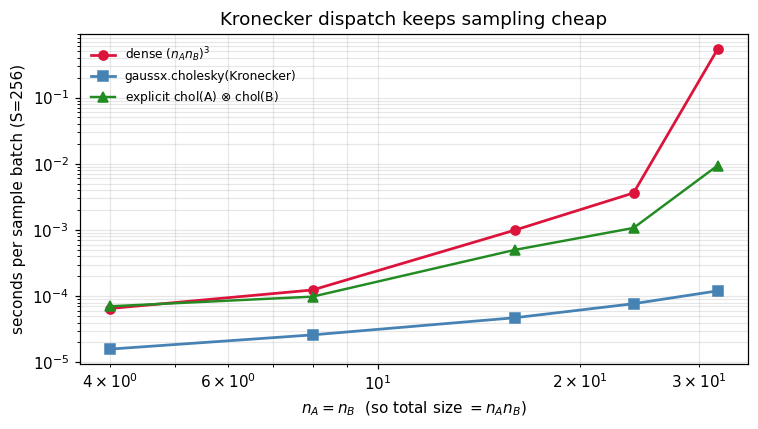

In [10]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(ns, records["dense"],      "o-", color="crimson",   lw=1.8, label=r"dense $(n_A n_B)^3$")
ax.plot(ns, records["structured"], "s-", color="steelblue", lw=1.8, label=r"gaussx.cholesky(Kronecker)")
ax.plot(ns, records["ref"],        "^-", color="forestgreen", lw=1.6, label=r"explicit chol(A) $\otimes$ chol(B)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$n_A = n_B$  (so total size $= n_A n_B$)")
ax.set_ylabel("seconds per sample batch (S=256)")
ax.set_title("Kronecker dispatch keeps sampling cheap")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## What *doesn't* dispatch yet

A few operators in `gaussx` currently have no closed-form structured Cholesky and fall back to materialising the matrix and calling `jnp.linalg.cholesky`. Each has a known smarter route — listing them here as future work and as a reminder that `gaussx.cholesky(op)` always *returns something correct*, just not always *something cheap*.

| Operator | Smart route (not yet wired) | Reference |
|----------|------------------------------|-----------|
| `Toeplitz` ($T_{ij} = t_{i-j}$) | Circulant embedding + FFT — $O(n \log n)$ sampling for stationary 1D processes | Wood & Chan (1994), *J. Comp. Graph. Stat.*; [gaussx#168](https://github.com/jejjohnson/gaussx/issues/168) |
| `KroneckerSum` ($A \oplus B = A \otimes I + I \otimes B$) | Eigendecomposition: $\lambda_{ij}^{A \oplus B} = \lambda_i^A + \lambda_j^B$, $V^{A \oplus B} = V^A \otimes V^B$ | Saatçi (2011), thesis; [gaussx#169](https://github.com/jejjohnson/gaussx/issues/169) |
| `SumKronecker` ($\sum_k A_k \otimes B_k$) | Conjugate-gradient + matfree Lanczos for $\Sigma^{1/2} \varepsilon$ | Pleiss et al. (2018), GPyTorch; [gaussx#170](https://github.com/jejjohnson/gaussx/issues/170) |

For now, on these operators `gaussx.cholesky` produces a dense `MatrixLinearOperator` and you sample as in section 1 (the dispatch path is just slower than it could be). The three tracking issues above carry full math + proposed APIs.

## Where the dispatch wins

| Setting | $\Sigma$ structure | Root used | Why |
|---------|--------------------|-----------|-----|
| Mean-field VI / factorised priors | Diagonal | [](#eq:diag-root) | Element-wise sqrt — no matrix anywhere |
| Spatio-temporal GPs (separable) | $K = K_{\rm space} \otimes K_{\rm time}$ | [](#eq:kron-root) | Two small Choleskys instead of one $(N_s N_t)^3$ |
| Independent ensembles / multi-output GPs | BlockDiag($\Sigma_1, \ldots$) | [](#eq:blockdiag-root) | Embarrassingly parallel per output |
| State-space / Markov GPs ([part 7](#)) | $\Lambda$ block-tridiagonal | [](#eq:blocktridiag-root) | Banded Cholesky → $O(N d^3)$ posterior sampling |
| Ensemble Kalman / low-rank GP priors | $\Sigma_0 + U D U^\top$ | [](#eq:lowrank-sampling) | Sample $L_0\varepsilon_0 + U\sqrt{D}\,\varepsilon_1$ — never factorise the sum |
| 2-Wasserstein / OT between Gaussians | symmetric sqrt $S$ | [](#eq:sym-sqrt) | Closed-form $W_2^2$ uses $\mathrm{tr}(\Sigma_1 + \Sigma_2 - 2(S_1 \Sigma_2 S_1)^{1/2})$ |
| Antithetic / coupled sampling | any deterministic root | [](#eq:reparam) | Same $\varepsilon$ across two distributions ⇒ correlated estimators |
| Reparameterised VI gradients | Cholesky $L$ | [](multivariate_gaussian.ipynb#eq:mvn-sample) | $\nabla_\theta L \cdot \varepsilon$ propagates cleanly through `jax.grad` |

:::{tip} Rule of thumb
- **Structured** $\Sigma$? `gaussx.cholesky` keeps the structure.
- Need same noise across two distributions? Pick **any one** root and reuse $\varepsilon$.
- Doing 2-Wasserstein / OT? Reach for **`gaussx.sqrt`** (symmetric).
- $\Sigma_0 + U D U^\top$? Don't factorise the sum — **add two independent draws**.
:::

## Recap

- Sampling = matvec against any root $R$ of $\Sigma$ ([](#eq:reparam)). gaussx exposes both Cholesky and symmetric sqrt; structured operators get structured roots.
- $\mathrm{chol}(A \otimes B) = \mathrm{chol}(A) \otimes \mathrm{chol}(B)$ ([](#eq:kron-root)) and $\mathrm{chol}(\mathrm{BlockDiag}) = \mathrm{BlockDiag}(\mathrm{chol})$ ([](#eq:blockdiag-root)) are both built into `gaussx.cholesky`.
- Low-rank updates avoid the closed-form root by injecting the rank correction as a *second independent draw* ([](#eq:lowrank-sampling)).
- Symmetric $S = S^\top$ ([](#eq:sym-sqrt)) is the right choice for 2-Wasserstein, antithetic sampling, and any setting that wants $S^2 = \Sigma$.

:::{seealso} Where this goes
- **Part 1 — Operator zoo** — every operator listed there has a custom Cholesky / sqrt dispatch under the hood.
- **Part 3 — Exact GPs** — sampling from the GP posterior $\mathcal{N}(\mu_\star, \Sigma_\star)$ uses `gaussx.cholesky` on the structured Schur complement from [0.7](conditional_distributions.ipynb).
- **Part 6 — Sparse / variational GPs** — the variational covariance $S_u$ is typically Cholesky-parameterised; reparameterised gradients flow through it.
- **Part 7 — State-space models** — square-root Kalman variants carry $L_t$ and update it directly via QR rotations.
:::

## References

- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press, App. A.4.
- Saatçi, Y. (2011). *Scalable Inference for Structured Gaussian Process Models*. PhD thesis, Cambridge.
- Higham, N. J. (2008). *Functions of Matrices: Theory and Computation*. SIAM. (Symmetric square roots.)
- Kingma, D. P. & Welling, M. (2014). Auto-encoding variational Bayes. *ICLR*. (Reparameterisation trick.)